<a href="https://colab.research.google.com/github/kthummalabtech23/sample/blob/main/Plant_Disease_Detection_(PROJECT).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Importing  the Librairies**

In [ ]:
# Install nightly package for some functionalities that aren't in alpha
# !pip install tf-nightly-gpu-2.0-preview

# Install TF Hub for TF2
!pip install tensorflow-gpu==2.0.0
!pip install tensorflow_hub


     |████████████████████████████████| 380.8MB 45kB/s 
     |████████████████████████████████| 450kB 46.6MB/s 
     |████████████████████████████████| 3.8MB 37.3MB/s 
ERROR: tensorflow 1.15.0 has requirement tensorboard<1.16.0,>=1.15.0, but you'll have tensorboard 2.0.2 which is incompatible.
ERROR: tensorflow 1.15.0 has requirement tensorflow-estimator==1.15.1, but you'll have tensorflow-estimator 2.0.1 which is incompatible.
  Found existing installation: tensorflow-estimator 1.15.1
    Uninstalling tensorflow-estimator-1.15.1:
      Successfully uninstalled tensorflow-estimator-1.15.1
  Found existing installation: tensorboard 1.15.0
    Uninstalling tensorboard-1.15.0:
      Successfully uninstalled tensorboard-1.15.0


In [1]:
from __future__ import absolute_import, division, print_function, unicode_literals


import tensorflow as tf
#tf.logging.set_verbosity(tf.logging.ERROR)
#tf.enable_eager_execution()

import tensorflow_hub as hub
import os
from tensorflow.keras.layers import Dense, Flatten, Conv2D
from tensorflow.keras import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers
#from keras import optimizers




In [2]:
# verify TensorFlow version

print("Version: ", tf.__version__)
print("Eager mode: ", tf.executing_eagerly())
print("Hub version: ", hub.__version__)
print("GPU is", "available" if tf.test.is_gpu_available() else "NOT AVAILABLE")


Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


Version:  2.19.0
Eager mode:  True
Hub version:  0.16.1
GPU is available


In [ ]:
# !rm -rf Dataset\ with\ Categories

### Loading dataset

In [5]:
from google.colab import files
uploaded = files.upload()

Saving tomato.zip.zip to tomato.zip.zip


In [7]:
!unzip tomato.zip.zip

Archive:  tomato.zip.zip
   creating: tomato dataset/
  inflating: tomato dataset/Tomato_Bacterial_spot - Shortcut.lnk  
  inflating: tomato dataset/Tomato_Early_blight - Shortcut.lnk  
  inflating: tomato dataset/Tomato_Late_blight - Shortcut.lnk  
  inflating: tomato dataset/Tomato_Leaf_Mold - Shortcut.lnk  
  inflating: tomato dataset/Tomato_Septoria_leaf_spot - Shortcut.lnk  
  inflating: tomato dataset/Tomato_Spider_mites_Two_spotted_spider_mite - Shortcut.lnk  
   creating: tomato dataset/Tomato__Target_Spot/
  inflating: tomato dataset/Tomato__Target_Spot/002213fb-b620-4593-b9ac-6a6cc119b100___Com.G_TgS_FL 8360.JPG  
  inflating: tomato dataset/Tomato__Target_Spot/003a5321-0430-42dd-a38d-30ac4563f4ba___Com.G_TgS_FL 8121.JPG  
  inflating: tomato dataset/Tomato__Target_Spot/0044d10f-7062-4655-8abd-9fffc5b2f152___Com.G_TgS_FL 7908.JPG  
  inflating: tomato dataset/Tomato__Target_Spot/007ec913-8cfe-43ed-b458-f041a17266ae___Com.G_TgS_FL 9844.JPG  
  inflating: tomato dataset/Tomato_

In [ ]:
# zip_file = tf.keras.utils.get_file(origin='/content/drive/My Drive/Dataset with Categories.zip',
#                                    fname='Dataset with Categories.zip', extract=True)
# #

### Prepare training and validation  dataset
Creating the training and validation directories

In [8]:
data_dir = os.path.join(os.path.abspath('Dataset with Categories'), 'Dataset')
train_dir = os.path.join(data_dir, 'train')
validation_dir = os.path.join(data_dir, 'validation')



In [9]:
import time
import os
from os.path import exists

def count(dir, counter=0):
    "returns number of files in dir and subdirs"
    for pack in os.walk(dir):
        for f in pack[2]:
            counter += 1
    return dir + " : " + str(counter) + "files"


In [10]:
print('total images for training :', count(train_dir))
print('total images for validation :', count(validation_dir))


total images for training : /content/Dataset with Categories/Dataset/train : 0files
total images for validation : /content/Dataset with Categories/Dataset/validation : 0files


In [ ]:
# !wget https://github.com/obeshor/Plant-Diseases-Detector/archive/master.zip
# !unzip master.zip;

In [12]:
import os

dataset_path = "/content/tomato dataset"

classes = os.listdir(dataset_path)

print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['Tomato__Tomato_YellowLeaf__Curl_Virus - Shortcut.lnk', 'Tomato__Target_Spot', 'Tomato_Bacterial_spot - Shortcut.lnk', 'Tomato_Early_blight - Shortcut.lnk', 'Tomato_Leaf_Mold - Shortcut.lnk', 'Tomato_Spider_mites_Two_spotted_spider_mite - Shortcut.lnk', 'Tomato__Tomato_mosaic_virus', 'Tomato_Septoria_leaf_spot - Shortcut.lnk', 'Tomato_Late_blight - Shortcut.lnk']
Number of classes: 9


In [13]:
print('Number of classes:',len(classes))

Number of classes: 9


In [14]:
# Select model from TensorFlow Hub
module_selection = ("inception_v3", 299, 2048)

handle_base, pixels, FV_SIZE = module_selection

# TensorFlow Hub model URL
MODULE_HANDLE = "https://tfhub.dev/google/tf2-preview/{}/feature_vector/4".format(handle_base)

# Image size required for the model
IMAGE_SIZE = (pixels, pixels)

print("Using {} with input size {} and output dimension {}".format(
    MODULE_HANDLE, IMAGE_SIZE, FV_SIZE))

# Batch size
BATCH_SIZE = 64

Using https://tfhub.dev/google/tf2-preview/inception_v3/feature_vector/4 with input size (299, 299) and output dimension 2048


In [15]:
# Inputs are suitably resized for the selected module. Dataset augmentation (i.e., random distortions of an image each time it is read) improves training, esp. when fine-tuning.
# Dataset path
dataset_path = "/content/tomato dataset"

# Data generator with automatic train-validation split
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Validation generator
validation_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

# Training generator with augmentation
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=40,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

Found 354 images belonging to 2 classes.
Found 1423 images belonging to 2 classes.


###Build the model


In [20]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models

# Load pretrained InceptionV3 model
base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=IMAGE_SIZE + (3,)
)

# Freeze base model
base_model.trainable = False

# Build model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(train_generator.class_indices), activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show model summary
model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,065,314 (84.17 MB)

 Trainable params: 262,530 (1.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [21]:
# Fine tuning option
do_fine_tuning = False  # set True if you want to fine tune

if do_fine_tuning:

    # Unfreeze last layers of InceptionV3
    base_model.trainable = True

    for layer in base_model.layers[:-30]:
        layer.trainable = False

else:

    # Freeze entire base model
    base_model.trainable = False


In [22]:
print("Building model with InceptionV3")

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(train_generator.num_classes, activation='softmax',
                          kernel_regularizer=tf.keras.regularizers.l2(0.0001))
])

model.summary()

Building model with InceptionV3


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,852,898 (87.18 MB)

 Trainable params: 1,050,114 (4.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

### Specify Loss Function and Optimizer

In [23]:
# Compile model specifying the optimizer learning rate

LEARNING_RATE = 0.001

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


### Train Model


In [24]:

EPOCHS = 6

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size
)

Epoch 1/6
22/22 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.8536 - loss: 0.4726 - val_accuracy: 0.9750 - val_loss: 0.0750
Epoch 2/6
 1/22 ━━━━━━━━━━━━━━━━━━━━ 4s 227ms/step - accuracy: 0.9531 - loss: 0.1554

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.9531 - loss: 0.1554 - val_accuracy: 0.9688 - val_loss: 0.0775
Epoch 3/6
22/22 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.9573 - loss: 0.1109 - val_accuracy: 0.9750 - val_loss: 0.0548
Epoch 4/6
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9844 - loss: 0.0740 - val_accuracy: 0.9750 - val_loss: 0.0563
Epoch 5/6
22/22 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9772 - loss: 0.0619 - val_accuracy: 0.9750 - val_loss: 0.0464
Epoch 6/6
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9844 - loss: 0.0445 - val_accuracy: 0.9750 - val_loss: 0.0472


###Check Performance
Ploting training and validation accuracy and loss

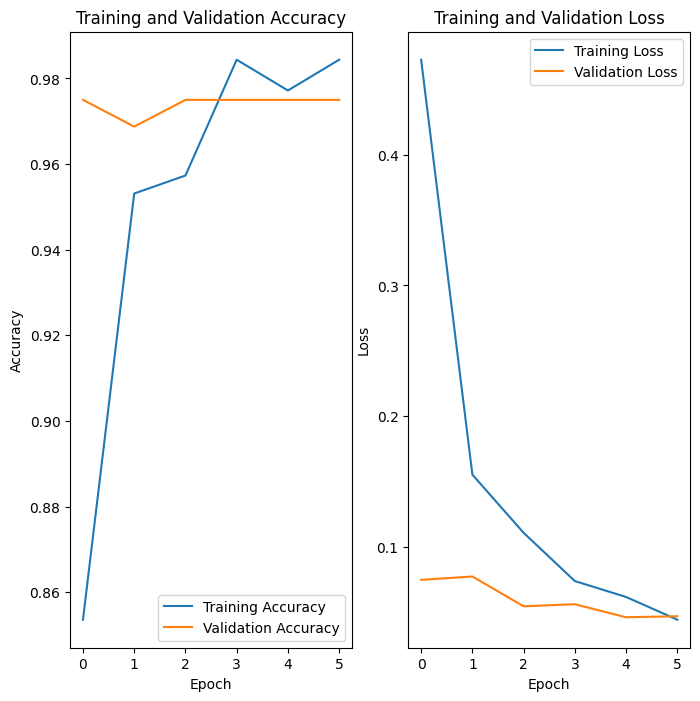

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Get metrics from training history
acc = history.history.get('accuracy')
val_acc = history.history.get('val_accuracy')

loss = history.history.get('loss')
val_loss = history.history.get('val_loss')

epochs_range = range(len(acc))

plt.figure(figsize=(8,8))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

# Loss graph
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.show()

### Testing


In [26]:
# Import libraries
import cv2
import numpy as np
import os

# Function to load image
def load_image(image_path):

    img = cv2.imread(image_path)
    img = cv2.resize(img, (IMAGE_SIZE[0], IMAGE_SIZE[1]))
    img = img / 255.0

    return img


# Prediction function
def predict(image_path):

    img = load_image(image_path)

    probabilities = model.predict(np.array([img]))[0]
    class_idx = np.argmax(probabilities)

    classes = list(train_generator.class_indices.keys())

    return {classes[class_idx]: float(probabilities[class_idx])}

SOURCE class: Tomato__Tomato_mosaic_virus
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
PREDICTED class: Tomato__Tomato_mosaic_virus confidence: 0.9349988698959351


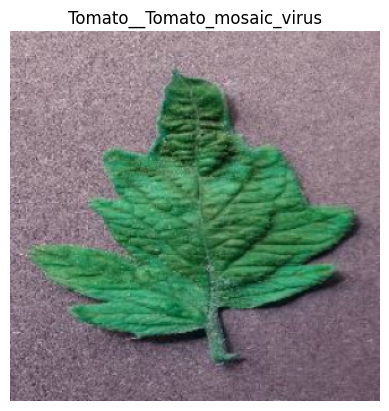

SOURCE class: Tomato__Target_Spot
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
PREDICTED class: Tomato__Target_Spot confidence: 0.999005913734436


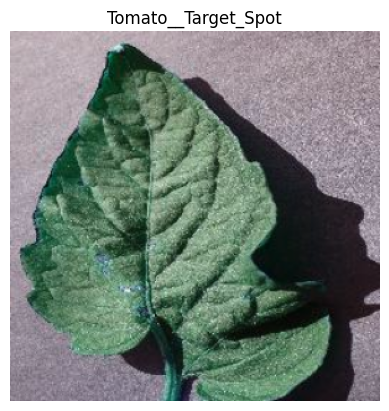

SOURCE class: Tomato__Target_Spot
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
PREDICTED class: Tomato__Target_Spot confidence: 0.999581515789032


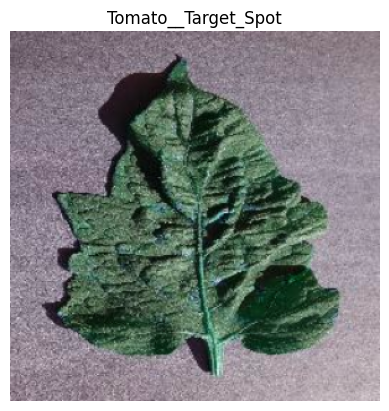

SOURCE class: Tomato__Target_Spot
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
PREDICTED class: Tomato__Target_Spot confidence: 0.9999349117279053


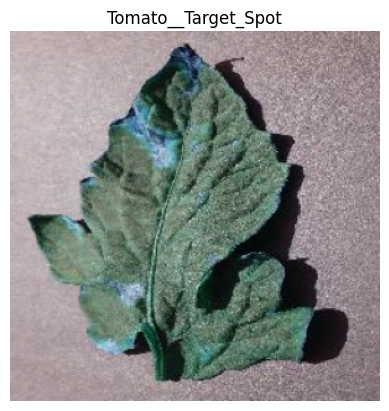

SOURCE class: Tomato__Target_Spot
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
PREDICTED class: Tomato__Target_Spot confidence: 0.9796465635299683


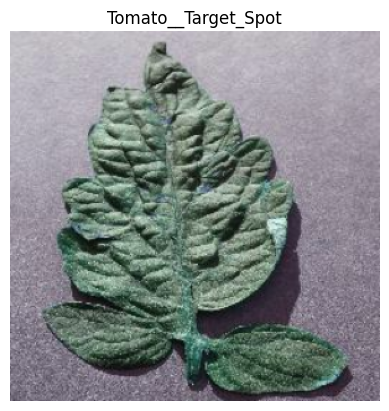

In [27]:
import random
import matplotlib.pyplot as plt

classes = list(train_generator.class_indices.keys())

# Test random validation images
for idx, filename in enumerate(random.sample(validation_generator.filepaths, 5)):

    print("SOURCE class:", os.path.basename(os.path.dirname(filename)))

    img = load_image(filename)

    prediction = predict(filename)

    pred_class = list(prediction.keys())[0]
    confidence = list(prediction.values())[0]

    print("PREDICTED class:", pred_class, "confidence:", confidence)

    plt.imshow(img)
    plt.title(pred_class)
    plt.axis('off')
    plt.show()

## Export saved model and convert it to TFLite


In [ ]:
# import time
# t = time.time()

# export_path = "/tmp/saved_models/{}".format(int(t))
# #tf.keras.experimental.export_saved_model(model, export_path)
# tf.keras.models.save_model(model, export_path, save_format="tf")

# export_path

In [ ]:
# # Now confirm that we can reload it, and it still gives the same results
# reloaded = tf.keras.experimental.load_from_saved_model(export_path, custom_objects={'KerasLayer':hub.KerasLayer})

In [ ]:
# def predict_reload(image):
#     probabilities = reloaded.predict(np.asarray([img]))[0]
#     class_idx = np.argmax(probabilities)

#     return {classes[class_idx]: probabilities[class_idx]}

In [ ]:
# for idx, filename in enumerate(random.sample(validation_generator.filenames, 2)):
#     print("SOURCE: class: %s, file: %s" % (os.path.split(filename)[0], filename))

#     img = load_image(filename)
#     prediction = predict_reload(img)
#     print("PREDICTED: class: %s, confidence: %f" % (list(prediction.keys())[0], list(prediction.values())[0]))
#     plt.imshow(img)
#     plt.figure(idx)
#     plt.show()

In [30]:
import os

# Create folder if it doesn't exist
os.makedirs("saved_models", exist_ok=True)

DISEASE_SAVED_MODEL = "saved_models/diseaseModel.keras"

# Save the trained model
model.save(DISEASE_SAVED_MODEL)

print("Model saved successfully!")

Model saved successfully!


In [31]:
from tensorflow.keras.models import load_model

disease_model = load_model(DISEASE_SAVED_MODEL)

print("Model loaded successfully!")
print(disease_model.summary())

Model loaded successfully!


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,953,128 (95.19 MB)

 Trainable params: 1,050,114 (4.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

 Optimizer params: 2,100,230 (8.01 MB)

None


In [32]:

# Convert the trained model to TensorFlow Lite

import os
os.makedirs("tflite_models", exist_ok=True)

TFLITE_MODEL = "tflite_models/plant_disease_model.tflite"

# Load the saved keras model
converter = tf.lite.TFLiteConverter.from_keras_model(disease_model)

# Convert model
tflite_model = converter.convert()

# Save the TFLite model
with open(TFLITE_MODEL, "wb") as f:
    f.write(tflite_model)

print("TFLite model saved successfully!")

Saved artifact at '/tmp/tmptxre6yhl'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name='input_layer_5')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  135992775952144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135992775960400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135992775955024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135992775953872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135992775954064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135992775951184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135992775953296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135992775955408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135992775952528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135992775954640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1359927759519

6/6 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step
Classification Report:

                             precision    recall  f1-score   support

        Tomato__Target_Spot       0.97      0.99      0.98       280
Tomato__Tomato_mosaic_virus       0.97      0.89      0.93        74

                   accuracy                           0.97       354
                  macro avg       0.97      0.94      0.96       354
               weighted avg       0.97      0.97      0.97       354



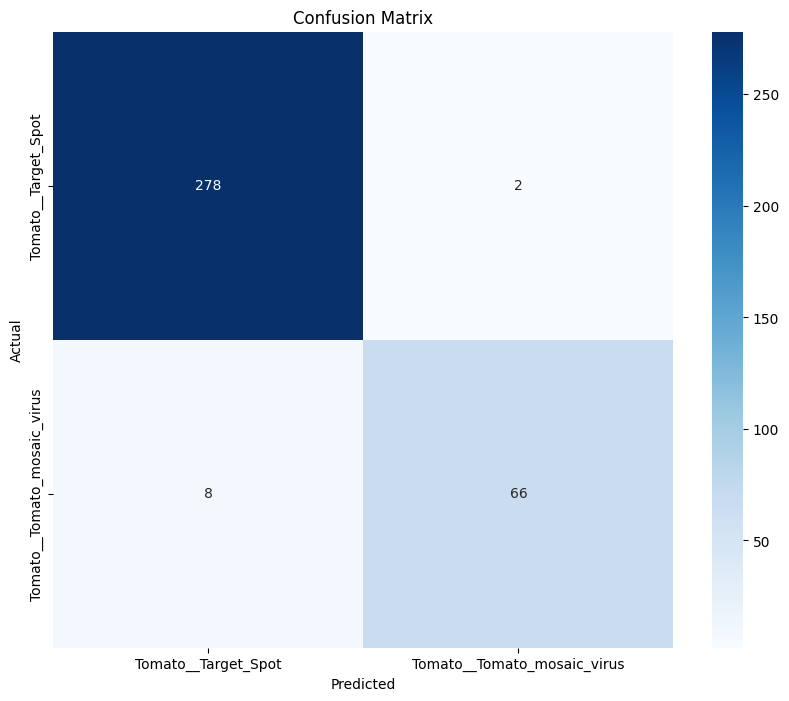

In [33]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Get true labels
true_labels = validation_generator.classes

# Predict labels
predictions = model.predict(validation_generator)
predicted_labels = np.argmax(predictions, axis=1)

# Class names
class_names = list(validation_generator.class_indices.keys())

# Classification report
print("Classification Report:\n")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()